# Part 1

- Limpeza
- Seleção de palavras frequentes
- Seleção de Duplas

In [350]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string
import ssl
from collections import Counter
import itertools
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, mean_squared_error, confusion_matrix, roc_curve
import joblib


In [351]:
'''!pip install watermark'''

'!pip install watermark'

In [352]:
%reload_ext watermark
%watermark -a "Matheus dos Anjos" --iversions

Author: Matheus dos Anjos

sklearn   : 1.6.1
matplotlib: 3.10.0
xgboost   : 3.0.4
numpy     : 2.0.2
joblib    : 1.5.2
nltk      : 3.9.1
pandas    : 2.2.2
seaborn   : 0.13.2



In [353]:
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

In [354]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [355]:
stop_words = set(stopwords.words('portuguese'))

In [356]:
df = pd.read_excel('/content/PROGRAMAÇÃO_ARTIGOS_CONGRESSO_CONSAD_2025.xlsx')

In [357]:
df.head()

,Id do trabalho,Área temática,Título,Nome dos autores (separado por vírgula),Código do resumo,Data e Horário de Apresentação,Sala
0,1201708,CULTURA ORGANIZACIONAL E A GESTÃO ESTRATÉGICA ...,A GESTÃO BUROCRÁTICA E SEUS EFEITOS NO CLIMA O...,"KÁRITA ALLEN,PAMELA NATIELLE BASILIO E SILVA,F...",1128006,26 de Agosto - 17h00,Sala 4
1,1207428,CULTURA ORGANIZACIONAL E A GESTÃO ESTRATÉGICA ...,"CULTURA ORGANIZACIONAL, VALORIZAÇÃO DE SERVIDO...","LUCIANO ARAUJO LIMA,NADJANARA LOPES DE ABREU A...",1119056,26 de Agosto - 17h00,Sala 5
2,1208275,CULTURA ORGANIZACIONAL E A GESTÃO ESTRATÉGICA ...,ECOAR - EDUCAÇÃO CORPORATIVA E APRENDIZAGEM EM...,"VANESSA DE OLIVEIRA SANTANA DERVINIS,FÁBIO DER...",1130109,27 de Agosto - 16h10,Sala 8
3,1211448,CULTURA ORGANIZACIONAL E A GESTÃO ESTRATÉGICA ...,PODCAST COMO ESTRATÉGIA INOVADORA DE COMUNICAÇ...,"REBECA RÊGO PEDROSA COSTA,HERLANE SUELE ALVES ...",1122770,26 de Agosto - 09h00,-
4,1215994,CULTURA ORGANIZACIONAL E A GESTÃO ESTRATÉGICA ...,"ASCENSÃO, PERMANÊNCIA E INFLUÊNCIA: O CASO DAS...","MARCELA CARVALHO,GUSTAVO MOREIRA TAVARES",1123635,27 de Agosto - 16h10,Sala 8


In [358]:
df1 = df[['Área temática', 'Título', 'Data e Horário de Apresentação']]

In [359]:
df1.head()

,Área temática,Título,Data e Horário de Apresentação
0,CULTURA ORGANIZACIONAL E A GESTÃO ESTRATÉGICA ...,A GESTÃO BUROCRÁTICA E SEUS EFEITOS NO CLIMA O...,26 de Agosto - 17h00
1,CULTURA ORGANIZACIONAL E A GESTÃO ESTRATÉGICA ...,"CULTURA ORGANIZACIONAL, VALORIZAÇÃO DE SERVIDO...",26 de Agosto - 17h00
2,CULTURA ORGANIZACIONAL E A GESTÃO ESTRATÉGICA ...,ECOAR - EDUCAÇÃO CORPORATIVA E APRENDIZAGEM EM...,27 de Agosto - 16h10
3,CULTURA ORGANIZACIONAL E A GESTÃO ESTRATÉGICA ...,PODCAST COMO ESTRATÉGIA INOVADORA DE COMUNICAÇ...,26 de Agosto - 09h00
4,CULTURA ORGANIZACIONAL E A GESTÃO ESTRATÉGICA ...,"ASCENSÃO, PERMANÊNCIA E INFLUÊNCIA: O CASO DAS...",27 de Agosto - 16h10


In [360]:
df1 = df1.set_index('Data e Horário de Apresentação')

In [361]:
df1.head()

,Área temática,Título
Data e Horário de Apresentação,,
26 de Agosto - 17h00,CULTURA ORGANIZACIONAL E A GESTÃO ESTRATÉGICA ...,A GESTÃO BUROCRÁTICA E SEUS EFEITOS NO CLIMA O...
26 de Agosto - 17h00,CULTURA ORGANIZACIONAL E A GESTÃO ESTRATÉGICA ...,"CULTURA ORGANIZACIONAL, VALORIZAÇÃO DE SERVIDO..."
27 de Agosto - 16h10,CULTURA ORGANIZACIONAL E A GESTÃO ESTRATÉGICA ...,ECOAR - EDUCAÇÃO CORPORATIVA E APRENDIZAGEM EM...
26 de Agosto - 09h00,CULTURA ORGANIZACIONAL E A GESTÃO ESTRATÉGICA ...,PODCAST COMO ESTRATÉGIA INOVADORA DE COMUNICAÇ...
27 de Agosto - 16h10,CULTURA ORGANIZACIONAL E A GESTÃO ESTRATÉGICA ...,"ASCENSÃO, PERMANÊNCIA E INFLUÊNCIA: O CASO DAS..."


In [362]:
cont_area_tematica = df1['Área temática'].value_counts()
print("Valores únicos e suas frequências:")
print(cont_area_tematica)

Valores únicos e suas frequências:
Área temática
CULTURA ORGANIZACIONAL E A GESTÃO ESTRATÉGICA DE PESSOAS: UM CAMINHO PARA EXCELÊNCIA    70
REINVENTANDO O ESTADO: DESAFIOS E OPORTUNIDADES                                         39
INVESTIMENTOS E GESTÃO DE ATIVOS                                                        37
GOVERNO DIGITAL E TRANSPARÊNCIA: CONSTRUINDO UM FUTURO MAIS ABERTO                      36
GESTÃO EFICIENTE E SUSTENTÁVEL: PRÁTICAS E DESAFIOS NA ADMINISTRAÇÃO PÚBLICA            30
INTELIGÊNCIA ARTIFICIAL E O FUTURO DA GESTÃO PÚBLICA                                    28
Name: count, dtype: int64


In [363]:
def limpar_texto(texto):
    try:
        texto = str(texto)
        texto = texto.lower()
        texto = ''.join([char for char in texto if char not in string.punctuation])
        tokens = word_tokenize(texto)
        palavras_filtradas = [palavra for palavra in tokens if palavra not in stop_words and len(palavra) > 2]
        return ' '.join(palavras_filtradas)
    except Exception as e:
        print(f"Erro ao processar texto: {texto}")
        print(f"Erro: {str(e)}")
        return ""

df1['Palavras_Chave'] = df1['Título'].apply(limpar_texto)

In [364]:
df1.head()

,Área temática,Título,Palavras_Chave
Data e Horário de Apresentação,,,
26 de Agosto - 17h00,CULTURA ORGANIZACIONAL E A GESTÃO ESTRATÉGICA ...,A GESTÃO BUROCRÁTICA E SEUS EFEITOS NO CLIMA O...,gestão burocrática efeitos clima organizaciona...
26 de Agosto - 17h00,CULTURA ORGANIZACIONAL E A GESTÃO ESTRATÉGICA ...,"CULTURA ORGANIZACIONAL, VALORIZAÇÃO DE SERVIDO...",cultura organizacional valorização servidores ...
27 de Agosto - 16h10,CULTURA ORGANIZACIONAL E A GESTÃO ESTRATÉGICA ...,ECOAR - EDUCAÇÃO CORPORATIVA E APRENDIZAGEM EM...,ecoar educação corporativa aprendizagem rede e...
26 de Agosto - 09h00,CULTURA ORGANIZACIONAL E A GESTÃO ESTRATÉGICA ...,PODCAST COMO ESTRATÉGIA INOVADORA DE COMUNICAÇ...,podcast estratégia inovadora comunicação apren...
27 de Agosto - 16h10,CULTURA ORGANIZACIONAL E A GESTÃO ESTRATÉGICA ...,"ASCENSÃO, PERMANÊNCIA E INFLUÊNCIA: O CASO DAS...",ascensão permanência influência caso líderes m...


In [365]:
palavras_series = pd.Series(' '.join(df1['Palavras_Chave']).split())
frequencia_palavras = palavras_series.value_counts()
df_palavras = pd.DataFrame({
    'Palavra': frequencia_palavras.index,
    'Frequência': frequencia_palavras.values
})

print("\nAnálise detalhada das palavras mais frequentes:")
print(df_palavras.head(10))

df_palavras.to_excel('analise_palavras_frequentes.xlsx', index=False)


Análise detalhada das palavras mais frequentes:
      Palavra  Frequência
0      gestão          78
1     pública          53
2     público          33
3    públicos          31
4    inovação          29
5     digital          27
6  eficiência          21
7       setor          21
8  estratégia          19
9      estado          18


In [366]:
palavras_lista = ' '.join(df1['Palavras_Chave']).split()
duplas_palavras = list(itertools.zip_longest(palavras_lista, palavras_lista[1:], fillvalue=''))
duplas_filtradas = [(p1, p2) for p1, p2 in duplas_palavras if p1 and p2]
frequencia_duplas = Counter(duplas_filtradas)

df_duplas = pd.DataFrame({
    'Dupla': [' '.join(dupla) for dupla in frequencia_duplas.keys()],
    'Frequência': list(frequencia_duplas.values())
}).sort_values('Frequência', ascending=False).reset_index(drop=True)

df_duplas.to_excel('analise_duplas_palavras_frequentes.xlsx', index=False)

In [367]:
print("\nAnálise detalhada das duplas de palavras mais frequentes:")
print(df_duplas.head(10))


Análise detalhada das duplas de palavras mais frequentes:
                     Dupla  Frequência
0            setor público          18
1           gestão pública          17
2    administração pública          15
3  inteligência artificial          14
4    transformação digital          10
5          serviço público           9
6           gestão pessoas           8
7      servidores públicos           7
8       gestão estratégica           6
9              estudo caso           6


# Part 2

- Filtrando por 'Área temática' e coletando duplas


In [368]:
df1.head()

,Área temática,Título,Palavras_Chave
Data e Horário de Apresentação,,,
26 de Agosto - 17h00,CULTURA ORGANIZACIONAL E A GESTÃO ESTRATÉGICA ...,A GESTÃO BUROCRÁTICA E SEUS EFEITOS NO CLIMA O...,gestão burocrática efeitos clima organizaciona...
26 de Agosto - 17h00,CULTURA ORGANIZACIONAL E A GESTÃO ESTRATÉGICA ...,"CULTURA ORGANIZACIONAL, VALORIZAÇÃO DE SERVIDO...",cultura organizacional valorização servidores ...
27 de Agosto - 16h10,CULTURA ORGANIZACIONAL E A GESTÃO ESTRATÉGICA ...,ECOAR - EDUCAÇÃO CORPORATIVA E APRENDIZAGEM EM...,ecoar educação corporativa aprendizagem rede e...
26 de Agosto - 09h00,CULTURA ORGANIZACIONAL E A GESTÃO ESTRATÉGICA ...,PODCAST COMO ESTRATÉGIA INOVADORA DE COMUNICAÇ...,podcast estratégia inovadora comunicação apren...
27 de Agosto - 16h10,CULTURA ORGANIZACIONAL E A GESTÃO ESTRATÉGICA ...,"ASCENSÃO, PERMANÊNCIA E INFLUÊNCIA: O CASO DAS...",ascensão permanência influência caso líderes m...


In [369]:
df['Área temática'].unique()

array(['CULTURA ORGANIZACIONAL E A GESTÃO ESTRATÉGICA DE PESSOAS: UM CAMINHO PARA EXCELÊNCIA',
       'GESTÃO EFICIENTE E SUSTENTÁVEL: PRÁTICAS E DESAFIOS NA ADMINISTRAÇÃO PÚBLICA',
       'GOVERNO DIGITAL E TRANSPARÊNCIA: CONSTRUINDO UM FUTURO MAIS ABERTO',
       'INTELIGÊNCIA ARTIFICIAL E O FUTURO DA GESTÃO PÚBLICA',
       'INVESTIMENTOS E GESTÃO DE ATIVOS',
       'REINVENTANDO O ESTADO: DESAFIOS E OPORTUNIDADES'], dtype=object)

In [370]:
df_cultura = df1[df1['Área temática'] == 'CULTURA ORGANIZACIONAL E A GESTÃO ESTRATÉGICA DE PESSOAS: UM CAMINHO PARA EXCELÊNCIA']
df_gestao = df1[df1['Área temática'] == 'GESTÃO EFICIENTE E SUSTENTÁVEL: PRÁTICAS E DESAFIOS NA ADMINISTRAÇÃO PÚBLICA']
df_governo = df1[df1['Área temática'] == 'GOVERNO DIGITAL E TRANSPARÊNCIA: CONSTRUINDO UM FUTURO MAIS ABERTO']
df_inteligencia = df1[df1['Área temática'] == 'INTELIGÊNCIA ARTIFICIAL E O FUTURO DA GESTÃO PÚBLICA']
df_investimentos = df1[df1['Área temática'] == 'INVESTIMENTOS E GESTÃO DE ATIVOS']
df_reinventando = df1[df1['Área temática'] == 'REINVENTANDO O ESTADO: DESAFIOS E OPORTUNIDADES']

In [371]:
df_inteligencia.head(3)

,Área temática,Título,Palavras_Chave
Data e Horário de Apresentação,,,
27 de Agosto - 16h10,INTELIGÊNCIA ARTIFICIAL E O FUTURO DA GESTÃO P...,O GERENCIAMENTO DE INFORMAÇÕES OSTENSIVAS E SI...,gerenciamento informações ostensivas sigilosas...
28 de Agosto - 08h30,INTELIGÊNCIA ARTIFICIAL E O FUTURO DA GESTÃO P...,INTELIGÊNCIA ARTIFICIAL GENERATIVA COMO ALIADA...,inteligência artificial generativa aliada prod...
28 de Agosto - 08h30,INTELIGÊNCIA ARTIFICIAL E O FUTURO DA GESTÃO P...,TECNOLOGIA PARA TODOS: A INTELIGÊNCIA ARTIFICI...,tecnologia todos inteligência artificial ferra...


In [372]:
def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word.lower() not in stop_words]
    return ' '.join(filtered_words)

In [373]:
df_cultura.head()

,Área temática,Título,Palavras_Chave
Data e Horário de Apresentação,,,
26 de Agosto - 17h00,CULTURA ORGANIZACIONAL E A GESTÃO ESTRATÉGICA ...,A GESTÃO BUROCRÁTICA E SEUS EFEITOS NO CLIMA O...,gestão burocrática efeitos clima organizaciona...
26 de Agosto - 17h00,CULTURA ORGANIZACIONAL E A GESTÃO ESTRATÉGICA ...,"CULTURA ORGANIZACIONAL, VALORIZAÇÃO DE SERVIDO...",cultura organizacional valorização servidores ...
27 de Agosto - 16h10,CULTURA ORGANIZACIONAL E A GESTÃO ESTRATÉGICA ...,ECOAR - EDUCAÇÃO CORPORATIVA E APRENDIZAGEM EM...,ecoar educação corporativa aprendizagem rede e...
26 de Agosto - 09h00,CULTURA ORGANIZACIONAL E A GESTÃO ESTRATÉGICA ...,PODCAST COMO ESTRATÉGIA INOVADORA DE COMUNICAÇ...,podcast estratégia inovadora comunicação apren...
27 de Agosto - 16h10,CULTURA ORGANIZACIONAL E A GESTÃO ESTRATÉGICA ...,"ASCENSÃO, PERMANÊNCIA E INFLUÊNCIA: O CASO DAS...",ascensão permanência influência caso líderes m...


In [374]:
palavras_lista = ' '.join(df_cultura['Palavras_Chave']).split()
duplas_palavras = list(itertools.zip_longest(palavras_lista, palavras_lista[1:], fillvalue=''))
duplas_filtradas = [(p1, p2) for p1, p2 in duplas_palavras if p1 and p2]
frequencia_duplas = Counter(duplas_filtradas)

df_duplas_cultura = pd.DataFrame({
    'Dupla': [' '.join(dupla) for dupla in frequencia_duplas.keys()],
    'Frequência': list(frequencia_duplas.values())
}).sort_values('Frequência', ascending=False).reset_index(drop=True)

df_duplas_cultura.to_excel('df_duplas_cultura.xlsx', index=False)

In [375]:
palavras_lista = ' '.join(df_gestao['Palavras_Chave']).split()
duplas_palavras = list(itertools.zip_longest(palavras_lista, palavras_lista[1:], fillvalue=''))
duplas_filtradas = [(p1, p2) for p1, p2 in duplas_palavras if p1 and p2]
frequencia_duplas = Counter(duplas_filtradas)

df_duplas_gestao = pd.DataFrame({
    'Dupla': [' '.join(dupla) for dupla in frequencia_duplas.keys()],
    'Frequência': list(frequencia_duplas.values())
}).sort_values('Frequência', ascending=False).reset_index(drop=True)

df_duplas_gestao.to_excel('df_duplas_gestao.xlsx', index=False)

In [376]:
palavras_lista = ' '.join(df_governo['Palavras_Chave']).split()
duplas_palavras = list(itertools.zip_longest(palavras_lista, palavras_lista[1:], fillvalue=''))
duplas_filtradas = [(p1, p2) for p1, p2 in duplas_palavras if p1 and p2]
frequencia_duplas = Counter(duplas_filtradas)

df_duplas_governo = pd.DataFrame({
    'Dupla': [' '.join(dupla) for dupla in frequencia_duplas.keys()],
    'Frequência': list(frequencia_duplas.values())
}).sort_values('Frequência', ascending=False).reset_index(drop=True)

df_duplas_governo.to_excel('df_duplas_governo.xlsx', index=False)

In [377]:
palavras_lista = ' '.join(df_inteligencia['Palavras_Chave']).split()
duplas_palavras = list(itertools.zip_longest(palavras_lista, palavras_lista[1:], fillvalue=''))
duplas_filtradas = [(p1, p2) for p1, p2 in duplas_palavras if p1 and p2]
frequencia_duplas = Counter(duplas_filtradas)

df_duplas_inteligencia = pd.DataFrame({
    'Dupla': [' '.join(dupla) for dupla in frequencia_duplas.keys()],
    'Frequência': list(frequencia_duplas.values())
}).sort_values('Frequência', ascending=False).reset_index(drop=True)

df_duplas_inteligencia.to_excel('df_duplas_inteligencia.xlsx', index=False)

In [378]:
palavras_lista = ' '.join(df_investimentos['Palavras_Chave']).split()
duplas_palavras = list(itertools.zip_longest(palavras_lista, palavras_lista[1:], fillvalue=''))
duplas_filtradas = [(p1, p2) for p1, p2 in duplas_palavras if p1 and p2]
frequencia_duplas = Counter(duplas_filtradas)

df_duplas_investimentos = pd.DataFrame({
    'Dupla': [' '.join(dupla) for dupla in frequencia_duplas.keys()],
    'Frequência': list(frequencia_duplas.values())
}).sort_values('Frequência', ascending=False).reset_index(drop=True)

df_duplas_inteligencia.to_excel('df_duplas_investimentos.xlsx', index=False)

In [379]:
palavras_lista = ' '.join(df_reinventando['Palavras_Chave']).split()
duplas_palavras = list(itertools.zip_longest(palavras_lista, palavras_lista[1:], fillvalue=''))
duplas_filtradas = [(p1, p2) for p1, p2 in duplas_palavras if p1 and p2]
frequencia_duplas = Counter(duplas_filtradas)

df_duplas_reinventando = pd.DataFrame({
    'Dupla': [' '.join(dupla) for dupla in frequencia_duplas.keys()],
    'Frequência': list(frequencia_duplas.values())
}).sort_values('Frequência', ascending=False).reset_index(drop=True)

df_duplas_reinventando.to_excel('df_duplas_reinventando.xlsx', index=False)

In [380]:
df_duplas_cultura['Frequência'].sum()

np.int64(659)

In [381]:
df_duplas_investimentos['Frequência'].sum()

np.int64(373)

In [382]:
df_duplas_reinventando['Frequência'].sum()

np.int64(371)

In [383]:
df_duplas_governo['Frequência'].sum()

np.int64(320)

In [384]:
df_duplas_gestao['Frequência'].sum()

np.int64(282)

In [385]:
df_duplas_inteligencia['Frequência'].sum()

np.int64(296)

# Part 3

- Criando e treinando modelo de Machine Learning Para previsão

- Regressão Logística


In [386]:
threshold = df_duplas['Frequência'].quantile(0.8)
df_duplas['target'] = (df_duplas['Frequência'] >= threshold).astype(int)

if df_duplas['target'].nunique() == 1:
    k = max(1, int(0.2 * len(df_duplas)))
    df_duplas['target'] = (df_duplas['Frequência'].rank(method='first', ascending=False) <= k).astype(int)
    print(f'Fallback aplicado: top {k} registros marcados como 1.')
else:
    print(f'Threshold usado: {threshold}')

Fallback aplicado: top 409 registros marcados como 1.


In [387]:
df_duplas.head()

,Dupla,Frequência,target
0,setor público,18,1
1,gestão pública,17,1
2,administração pública,15,1
3,inteligência artificial,14,1
4,transformação digital,10,1


In [388]:
df_duplas.tail()

,Dupla,Frequência,target
2044,teoria interseccional,1,0
2045,estruturais teoria,1,0
2046,silêncios estruturais,1,0
2047,rompendo silêncios,1,0
2048,processual análise,1,0


In [389]:
print(df_duplas['target'].value_counts())

target
0    1640
1     409
Name: count, dtype: int64


In [390]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df_duplas['Dupla'])
y = df_duplas['target']

'''O vectorizer quebra palavras individuais, as duplas se separaram aqui'''

In [391]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y)

In [392]:
model = LogisticRegression(max_iter=1000, class_weight='balanced', solver='liblinear')
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, solver='liblinear')

In [393]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.82      0.84       328
           1       0.42      0.51      0.46        82

    accuracy                           0.76       410
   macro avg       0.64      0.67      0.65       410
weighted avg       0.78      0.76      0.77       410



In [394]:
feature_names = vectorizer.get_feature_names_out()
coefs = model.coef_[0]

top_pos_idx = np.argsort(coefs)[-15:][::-1]
top_neg_idx = np.argsort(coefs)[:15]

print("Duplas que MAIS indicam alta demanda:")
for i in top_pos_idx:
    print(f"{feature_names[i]}: {coefs[i]:.4f}")

print("\nDuplas que MAIS indicam baixa demanda:")
for i in top_neg_idx:
    print(f"{feature_names[i]}: {coefs[i]:.4f}")


Duplas que MAIS indicam alta demanda:
estaduais: 1.8176
inteligência: 1.8074
artificial: 1.8069
sigepe: 1.7653
privada: 1.7422
informações: 1.6625
compliance: 1.6480
pública: 1.6222
georreferenciamento: 1.5434
melhorias: 1.5420
legis: 1.5204
serviço: 1.4878
planejamento: 1.4634
assédio: 1.4442
riscos: 1.4153

Duplas que MAIS indicam baixa demanda:
estratégias: -1.2166
metodologia: -1.1317
implementação: -1.0861
comunicação: -1.0099
institucional: -0.9933
solução: -0.9833
instrumento: -0.9226
integrado: -0.9119
contratação: -0.8826
aprendizagem: -0.8737
plataforma: -0.8363
implantação: -0.7865
capacitação: -0.7844
perspectiva: -0.7652
sustentabilidade: -0.7445


In [395]:
df_coef = pd.DataFrame({
    'Dupla': feature_names,
    'Coeficiente': coefs
})

In [396]:
top_pos = df_coef.sort_values(by='Coeficiente', ascending=False).head(15)
top_neg = df_coef.sort_values(by='Coeficiente', ascending=True).head(15)

# Part 4

- Arquitetura XGBoost


In [399]:
vectorizer = TfidfVectorizer(ngram_range=(1,2), max_features=5000)

In [400]:
X = vectorizer.fit_transform(df_duplas['Dupla'])
y = df_duplas['target']

In [401]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)


In [402]:
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42)

In [403]:
param_grid = {
    'n_estimators': [200, 400],
    'learning_rate': [0.05, 0.1],
    'max_depth': [4, 6, 8],
    'subsample': [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9]}

In [404]:
grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    verbose=2,
    n_jobs=-1)

In [344]:
grid.fit(X_train, y_train)

Fitting 3 folds for each of 48 candidates, totalling 144 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [19:25:54] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.7, 0.9],
                         'learning_rate': [0.05, 0.1], 'max_depth': [4, 6, 8],
                         'n_estimators': [200, 400], 'subsample': [0.7, 0.9]},
             scoring='roc_auc', verbose=2)

In [345]:
print("Melhores parâmetros encontrados:")
print(grid.best_params_)
print(f"Melhor AUC (treino CV): {grid.best_score_:.4f}")

Melhores parâmetros encontrados:
{'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.7}
Melhor AUC (treino CV): 0.6183


In [346]:
best_xgb = grid.best_estimator_
y_prob = best_xgb.predict_proba(X_test)[:, 1]
y_pred = best_xgb.predict(X_test)

auc_test = roc_auc_score(y_test, y_prob)
print(f"AUC no teste: {auc_test:.4f}")

AUC no teste: 0.6012


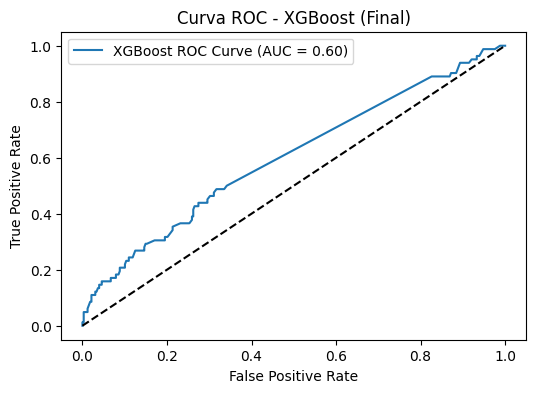

In [348]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"XGBoost ROC Curve (AUC = {auc_test:.2f})")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - XGBoost (Final)")
plt.legend()
plt.show()


# Part 5

- Resultado Final


/tmp/ipython-input-3217412145.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Coeficiente", y="Dupla", data=top_pos, palette="Greens_r")


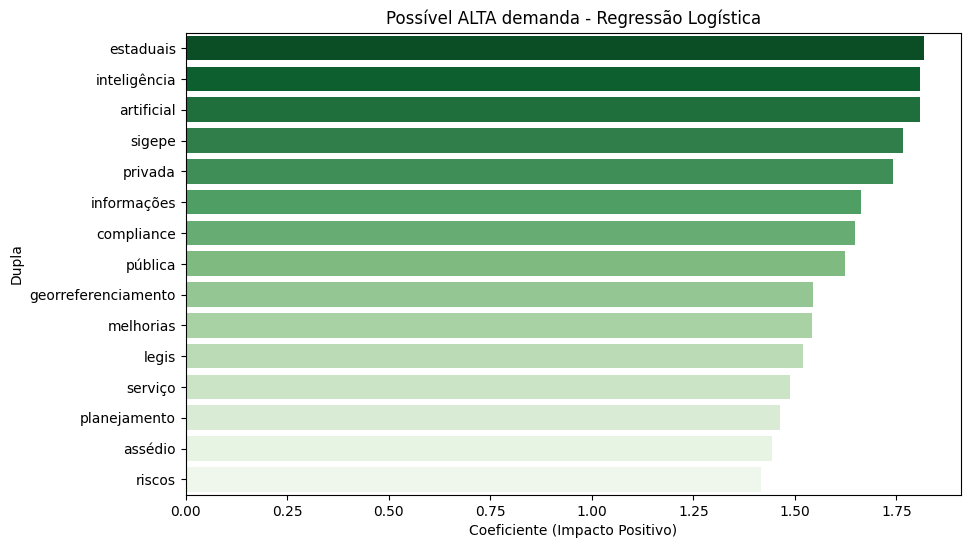

In [406]:
plt.figure(figsize=(10,6))
sns.barplot(x="Coeficiente", y="Dupla", data=top_pos, palette="Greens_r")
plt.title("Previsão de alta demanda com Regressão Logística")
plt.xlabel("Coeficiente (Impacto Positivo)")
plt.ylabel("Dupla")
plt.show()

/tmp/ipython-input-3535278518.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Coeficiente", y="Dupla", data=top_neg, palette="Reds_r")


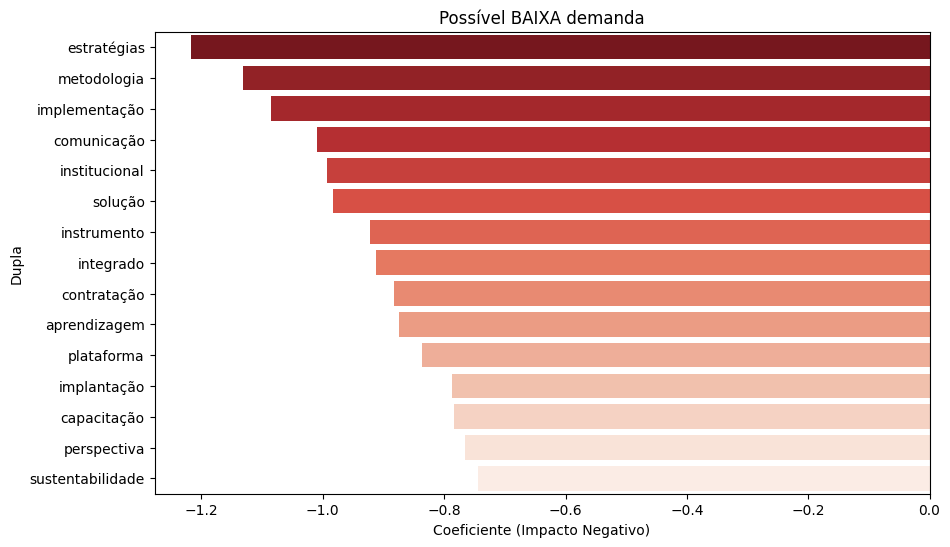

In [407]:
plt.figure(figsize=(10,6))
sns.barplot(x="Coeficiente", y="Dupla", data=top_neg, palette="Reds_r")
plt.title("Previsão de baixa demanda com Regressão Logística")
plt.xlabel("Coeficiente (Impacto Negativo)")
plt.ylabel("Dupla")
plt.show()

/tmp/ipython-input-2457538046.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices],


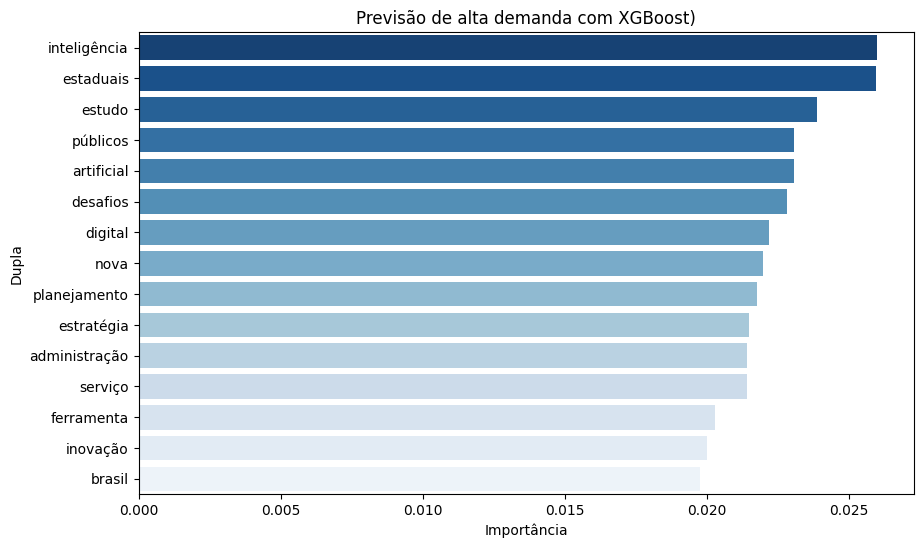

In [408]:
importances = best_xgb.feature_importances_
indices = np.argsort(importances)[-15:][::-1]

plt.figure(figsize=(10,6))
sns.barplot(x=importances[indices],
            y=np.array(vectorizer.get_feature_names_out())[indices],
            palette="Blues_r")
plt.title("Previsão de alta demanda com XGBoost)")
plt.xlabel("Importância")
plt.ylabel("Dupla")
plt.show()
